## Run DOLPHOT on simulated Rosesim images and do artificial star injection tests

In [1]:
# Import packages
%load_ext autoreload
%autoreload 2

import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import os
from astropy.io import fits
from kuaizi.display import display_single

import romanisim
import romanisim.parameters
import romanisim.bandpass
from astropy.table import Table, hstack, vstack
import astropy.units as u
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

import sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
sys.path.append('/home/jiaxuanl/Research/Roman_Cycle1/')
from display import show_image_wcs

from scipy.stats import binned_statistic
import kuaizi
kuaizi.set_matplotlib(style='nature', usetex=False, dpi=90)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import ripples

## 1. Check DOLPHOT residuals

In [4]:
exptime = 600
host = 'dw1e7_3.5Mpc_nap_sfh'
# host = 'cena'

In [5]:
os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
!pwd

/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/dw1e7_3.5Mpc_nap_sfh


/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/dw1e7_3.5Mpc_nap_sfh


(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7fad667ac2f0>})

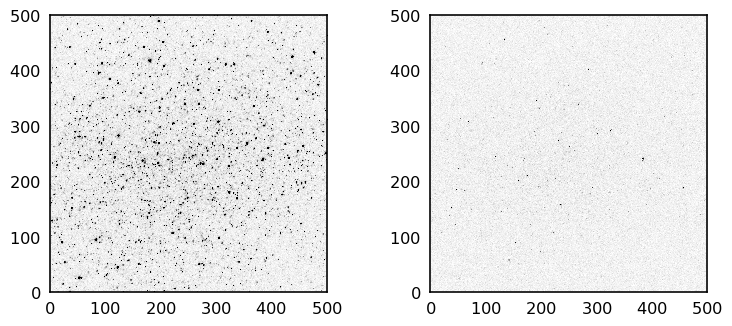

(<Figure size 900x360 with 2 Axes>,
 <Axes: >,
 {'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x7f48b5f7b620>})

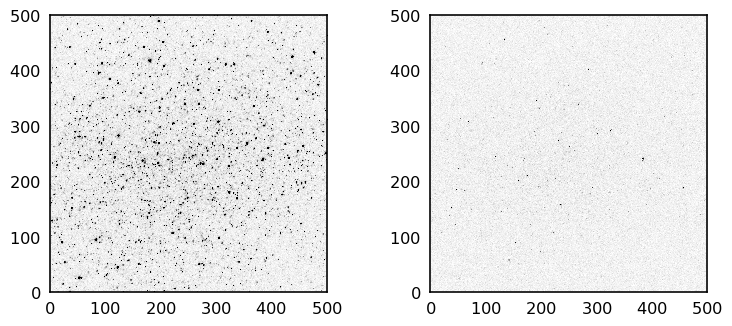

In [6]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

exptime = 600
hdu = fits.open(f'./F106_{exptime}s_LINEGAP5_1.0.fits')
_, _, norm = show_image_wcs(hdu[0].data[800:1300,800:1300], fig=fig, ax=ax1, percl=99)
w = WCS(hdu[0].header)

# The residual image after DOLPHOT. You'll see lots of point sources disappear.
# hdu = fits.open(f'./{host}_{exptime}s/{host}_{exptime}s.phot.1.res.fits')

host = 'dw1e7_napping_sfh'
exptime = 3000

hdu = fits.open(f'./{host}_{exptime}s.phot.1.res.fits')
show_image_wcs(hdu[0].data[800:1300,800:1300], fig=fig, ax=ax2, scale_args=norm)

In [7]:
# fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

# exptime = 10272
# # hdu = fits.open(f'../raw/F158_{exptime}s.fits')
# hdu = fits.open(f'./F158_{exptime}s.fits')
# _, _, norm = show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax1)#, percl=93)

# # hdu = fits.open(f'./F158_{exptime}s.fits')
# hdu = fits.open(f'./ngc253_{exptime}s/ngc253_{exptime}s.phot.1.res.fits')
# show_image_wcs(hdu[0].data[:1000, :1000], fig=fig, ax=ax2)#, scale_args=norm)

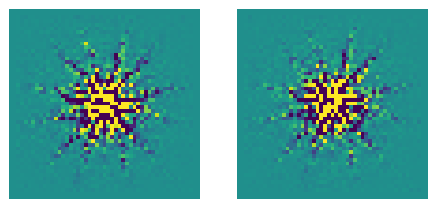

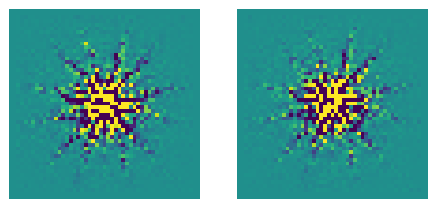

In [8]:
# This shows the "correction" term to the fiducial Roman PSF templates, as we downloaded when installing DOLPHOT
# exptime = 600

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(6, 3))
hdu = fits.open(f'./{host}_{exptime}s.phot.1.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax1);
hdu = fits.open(f'./{host}_{exptime}s.phot.4.psf.fits')
display_single(hdu[0].data, xsize=4, ysize=4, scale_bar=False, ax=ax2);

## 2. Check the DOLPHOT catalog

In [9]:
from rosesim.utils import read_dolphot_cat, xmatch_true_meas

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f158'] > snr
    flag &= cat['snr_f106'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    # flag &= (cat['qflag_f158'] <= 4)
    # flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3)
    return flag

In [10]:
from pathlib import Path
import re

In [11]:
from rosesim import Roman_zp_AB_Vega_parsec

In [12]:
exptime = 3000
# os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/DOLPHOT/{host}/')
cat = read_dolphot_cat(f'./{host}_{exptime}s_fitsky2.phot', 
                       f'./{host}_{exptime}s_fitsky2.phot.columns', fake=False)

Filters: ['F106', 'F158']


Filters: ['F106', 'F158']


In [13]:
len(cat)

121660

In [32]:
len(cat)

87003

Text(0, 0.5, 'sharp')

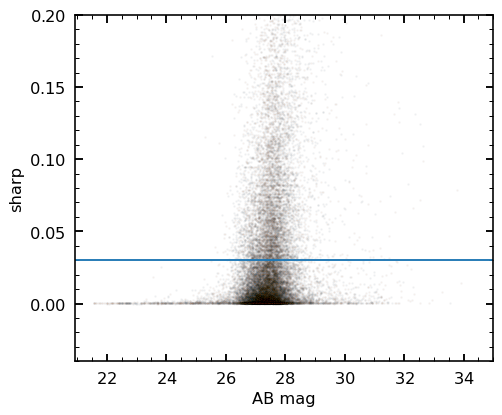

Text(0, 0.5, 'sharp')

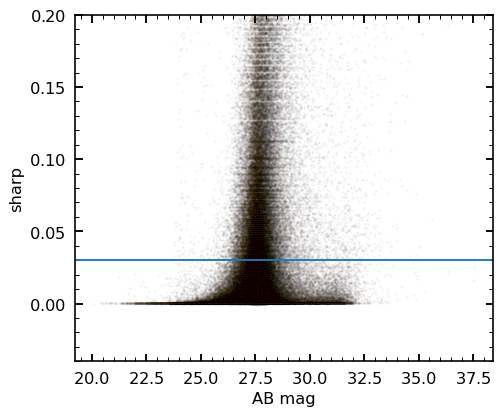

Text(0, 0.5, 'sharp')

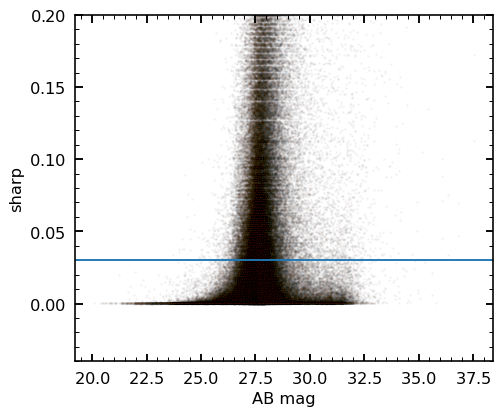

In [14]:
cat['ra'], cat['dec'] = w.all_pix2world(cat['x'], cat['y'], 1)

plt.scatter(cat['mag_ab_f106'], abs(cat['sharp_f106'])**2, s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], abs(cat['sharp_f158'])**2, s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)
plt.xlabel('AB mag')
plt.ylabel('sharp')

In [15]:
# plt.scatter(cat['crowd_f106'], cat['crowd_f106'] - cat['crowd_f158'], s=3)
# plt.ylim(-1, 1)

In [ ]:
plt.scatter(cat['mag_ab_f106'], (cat['crowd_f106']), s=1, alpha=0.04)
plt.scatter(cat['mag_ab_f158'], (cat['crowd_f158']), s=1, alpha=0.04)
plt.ylim(-0.04, 0.2)
plt.axhline(0.03)

plt.xlabel('AB mag')
plt.ylabel('crowd')

In [17]:
npix  = 5
1 / (50 * npix * 0.11**2) # star per arcsec2

0.3305785123966942

0.3305785123966942

In [24]:
200000 / (3600**2)

0.015432098765432098

In [18]:
cat['good_flag'] = quality_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03})
cat['star_flag'] = point_source_cut(cat, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03})

In [19]:
np.sum(cat['star_flag']), np.sum(cat['good_flag'])

(np.int64(20605), np.int64(52827))

In [41]:
from ripples.utils import apply_obs_model_two_band
hlwas_completeness_dict = {'F106': [26.8276654500533, 0.4966708077077806], 
                           'F158': [26.472505389291722, 0.4872157948732412]} # HLWAS depth, sharp=0.03
hlwas_mag_uncertainty_dict = {'F106': [0.33745871, -9.60010621], 
                              'F158': [0.33819561, -9.55362927]} # HLWAS depth, sharp=0.03

truth_cat = Table.read('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_3.5Mpc_napping_sfh_n253/temp/pts_table.ecsv')

### Pertube the truth cat using completeness and mag uncertainty
rng = np.random.default_rng(123)
depth_HLWAS = 5

# Ultra-faint dwarf sources
ufd = apply_obs_model_two_band(
    -2.5 * np.log10(truth_cat["F106"]), 
    -2.5 * np.log10(truth_cat["F158"]),
    bands=['F106', 'F158'],
    completeness_dict=hlwas_completeness_dict,
    mag_uncertainty_dict=hlwas_mag_uncertainty_dict,
    rng=rng,
    detection="both",     # since you care about colors
    depth_HLWAS=depth_HLWAS
)
ufd['RA'] = truth_cat['ra']
ufd['DEC'] = truth_cat['dec']
ufd['MC_SOURCE_ID'] = 1 # mark UFD stars

In [158]:
import artpop
iso = artpop.Isochrone.from_parsec(os.path.join(os.environ['ROSESIM_DATA_PATH'], 'PARSEC/PARSEC_v1.2S_Roman_vega_nTP20.dat'),
                                   log_age=9.0, MH=-1.5)
iso.mag_table.rename_columns(iso.filters, [item.replace('mag', '') for item in iso.filters])
from rosesim import Roman_zp_AB_Vega_parsec
# convert Vega to AB
for filt in iso.mag_table.colnames:
    iso.mag_table[filt] += Roman_zp_AB_Vega_parsec[filt]

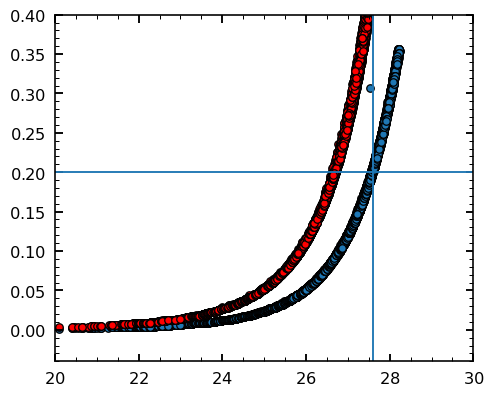

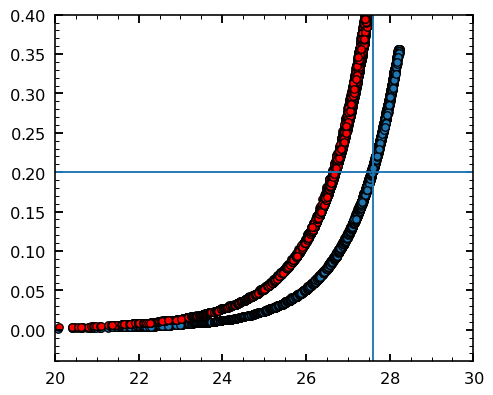

In [20]:
# plt.scatter(cat['mag_ab_f158_sub4_dither0'], cat['mag_err_f158_sub4_dither0'])
flag = cat['star_flag']
plt.scatter(cat['mag_ab_f158'][flag], cat['mag_err_f158'][flag])
# plt.scatter(cat['mag_ab_f158'], cat['mag_err_f158'], c=cat['obj_type'])
# plt.colorbar()

plt.scatter(cat['mag_ab_f158_linegap5_1_0'][flag], cat['mag_err_f158_linegap5_1_0'][flag], c='r')

# mag = np.linspace(20, 29, 100)
# plt.plot(mag, mag_uncertainty_func(mag, 0.33950503, -10.01496388))

plt.ylim(-0.04, 0.4)
plt.xlim(20, 30)
plt.axvline(27.6)
plt.axhline(1/5)

Text(0, 0.5, 'F158 [AB mag]')

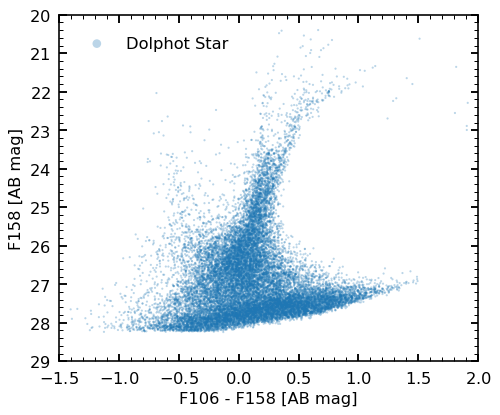

In [29]:
# plt.scatter(cat['mag_ab_f106'] - cat['mag_ab_f158'], cat['mag_ab_f158'],
#             ec='none', s=3, label='Dolphot all')

# flag = (cat['good_flag']) & (~cat['star_flag'])
# plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
#             ec='none', s=3, label='Dolphot Good')

flag = cat['star_flag']
plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
            ec='none', s=3, label='Dolphot Star', alpha=0.3)

# plt.scatter(cat[flag]['mag_ab_f106_sub4_dither0'] - cat[flag]['mag_ab_f158_sub4_dither0'], cat[flag]['mag_ab_f158_sub4_dither0'], 
#             ec='none', s=3, label='Dolphot Single')

# plt.scatter(-2.5 * np.log10(truth_cat['F106'] / truth_cat['F158']), -2.5 * np.log10(truth_cat['F158']), 
#             fc='none', s=60, alpha=0.1)

# plt.scatter(ufd['MAG_F106'] - ufd['MAG_F158'], ufd['MAG_F158'], ec='none', s=3)

# dmod = 5 * np.log10(4) + 25
# flag = iso.eep <= 7

# filt1, filt2 = "F106", "F158"

# plt.plot((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          c='darkviolet', lw=3, label='Isochrone')

# flag = iso.eep >= 7
# plt.scatter((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
#          iso.mag_table[filt2][flag] + dmod, 
#          fc='darkviolet', ec='none', s=1)


plt.xlim(-1.5, 2)
plt.ylim(29, 20)
plt.xlim()
plt.legend(markerscale=4.0)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

Text(0, 0.5, 'F158 [AB mag]')

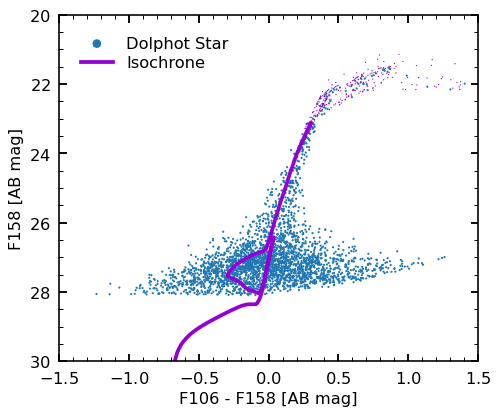

In [164]:
# plt.scatter(cat['mag_ab_f106'] - cat['mag_ab_f158'], cat['mag_ab_f158'],
#             ec='none', s=3, label='Dolphot all')

# flag = (cat['good_flag']) & (~cat['star_flag'])
# plt.scatter(cat[flag]['mag_ab_f106'] - cat[flag]['mag_ab_f158'], cat[flag]['mag_ab_f158'], 
#             ec='none', s=3, label='Dolphot Good')

flag = out['meas_star_flag']
plt.scatter(out[flag]['meas_mag_ab_f106'] - out[flag]['meas_mag_ab_f158'], out[flag]['meas_mag_ab_f158'], 
            ec='none', s=3, label='Dolphot Star')

# plt.scatter(-2.5 * np.log10(out[flag]['true_F106'] / out[flag]['true_F158']), -2.5 * np.log10(out[flag]['true_F158']), 
            # fc='none', s=60, alpha=0.1, label='Truth')

# plt.scatter(ufd['MAG_F106'] - ufd['MAG_F158'], ufd['MAG_F158'], ec='none', s=3)

dmod = 5 * np.log10(4) + 25
flag = iso.eep <= 7

filt1, filt2 = "F106", "F158"

plt.plot((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
         iso.mag_table[filt2][flag] + dmod, 
         c='darkviolet', lw=3, label='Isochrone')

flag = iso.eep >= 7
plt.scatter((iso.mag_table[filt1] - iso.mag_table[filt2])[flag], 
         iso.mag_table[filt2][flag] + dmod, 
         fc='darkviolet', ec='none', s=1)


plt.xlim(-1.5, 1.5)
plt.ylim(30, 20)
plt.xlim()
plt.legend(markerscale=4.0)
plt.xlabel('F106 - F158 [AB mag]')
plt.ylabel('F158 [AB mag]')

## Spatial match

In [24]:
temp = cat[cat['star_flag']]
temp_truth = truth_cat[~np.isnan(truth_cat['ra'])]
# temp_truth = temp_truth[(-2.5 * np.log10(temp_truth['F158']) < 27)]
out = xmatch_true_meas(temp_truth, temp, radius=0.4 * u.arcsec)

NameError: name 'truth_cat' is not defined

Text(0, 0.5, 'Completeness')

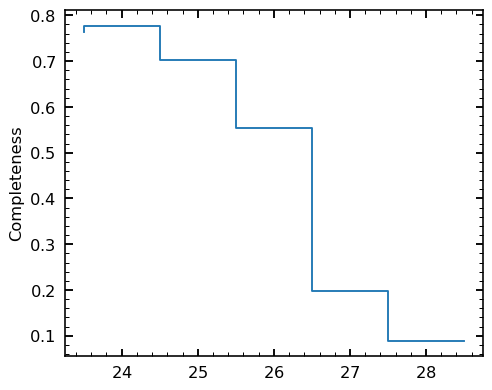

Text(0, 0.5, 'Completeness')

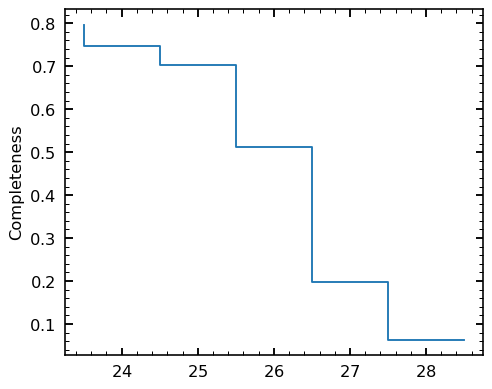

NameError: name 'temp_truth' is not defined

In [25]:
out = xmatch_true_meas(temp, temp_truth, radius=0.4 * u.arcsec)

flag = (out['has_match'])
n_obs, bin_edges = np.histogram(-2.5 * np.log10(out[flag]['meas_F158']), bins=np.linspace(23, 29, 7))
n_true, bin_edges = np.histogram(-2.5 * np.log10(out['meas_F158']), bins=np.linspace(23, 29, 7))
cen = 0.5 * (bin_edges[1:] + bin_edges[:-1])
plt.step(cen, n_obs / n_true)
plt.ylabel('Completeness')

Text(0, 0.5, 'Dec [deg]')

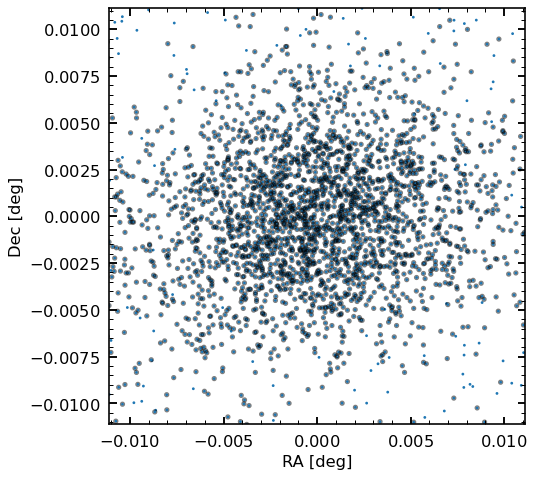

Text(0, 0.5, 'Dec [deg]')

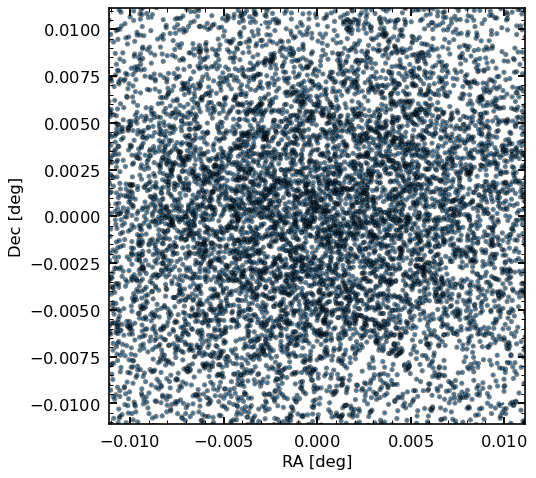

NameError: name 'temp' is not defined

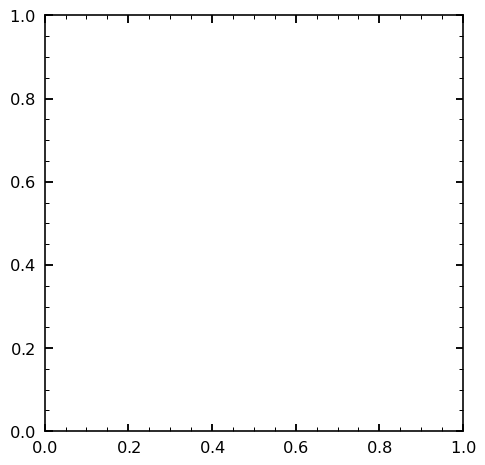

In [23]:
obs_ra, obs_dec = 150, 0

fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(temp['ra'] - obs_ra, temp['dec'] - obs_dec, s=5, ec='none')

flag = (out['has_match'])
plt.scatter(out[flag]['true_ra'] - obs_ra, out[flag]['true_dec'] - obs_dec, s=10, fc='none', alpha=0.5)

# plt.scatter(out[flag]['meas_ra'] - obs_ra, out[flag]['meas_dec'] - obs_dec, s=100, fc='none', alpha=0.5)
# flag = (-2.5 * np.log10(truth_cat['F158']) < 27)
# plt.scatter(truth_cat[flag]['ra'] - obs_ra, truth_cat[flag]['dec'] - obs_dec, s=10, fc='none', alpha=0.5)

extent = 40
plt.xlim(-extent/3600, extent/3600)
plt.ylim(-extent/3600, extent/3600)
plt.gca().set_aspect('equal')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')

## 3. Artificial Star Tests to derive completeness and photometric uncertainties

We use a function `quality_cut` to cull the catalog. If the `good_flag` is true, it passes the QA criteria in the `quality_cut` function. See here for more information on QA cuts: https://dolphot-jwst.readthedocs.io/en/latest/post-processing/catalogs.html

We also assume that the oc

In [32]:
from rosesim.utils import read_dolphot_cat, delta_m_scatter_vs_mag, logistic_completeness, mag_uncertainty_func, fit_logistic_completeness
from rosesim.utils import read_dolphot_cat, xmatch_true_meas
from rosesim import Roman_zp_AB_Vega_parsec

def quality_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = cat['snr_f106'] > snr
    flag &= cat['snr_f158'] > snr
    flag &= (cat['crowd_f106'] < crowd['f106'])
    flag &= (cat['crowd_f158'] < crowd['f158'])
    flag &= (cat['qflag_f158'] <= 4)
    flag &= (cat['qflag_f106'] <= 4)
    flag &= (cat['obj_type'] <= 2) # (1=bright star, 2=faint, 3=elongated, 4=hot pixel, 5=extended)
    flag &= (cat['pass_det'] < 3)
    return flag


def point_source_cut(cat, snr=5, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}):
    flag = quality_cut(cat, snr=snr, crowd=crowd, sharp=sharp)
    flag &= (cat['sharp_f106']**2 < sharp['f106'])
    flag &= (cat['sharp_f158']**2 < sharp['f158'])
    flag &= (cat['chi_f106'] < 3)
    flag &= (cat['chi_f158'] < 3) # this is tbd
    return flag

In [45]:
# Here we load the AST output catalog,
exptime = 3000
# fake = read_dolphot_cat(f'./{host}_{exptime}s/fake_n253_{exptime}s.fake', f'./{host}_{exptime}s.phot.columns', fake=True)
fake = read_dolphot_cat(f'./fake_dw1e7_napping_sfh_3000s_fitsky2.fake', f'./dw1e7_napping_sfh_3000s_fitsky2.phot.columns', fake=True)

crowd_cut = 0.5
# sharp_cut = 0.04
sharp_cut = 0.03

# We apply QA cuts
snr_cut = 3
fake['star_flag'] = point_source_cut(fake, snr=snr_cut, 
                                     crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                                     sharp={'f158': sharp_cut, 'f106': sharp_cut})
fake['good_flag'] = quality_cut(fake, snr=snr_cut, 
                               crowd={'f158': crowd_cut, 'f106': crowd_cut}, 
                               sharp={'f158': sharp_cut, 'f106': sharp_cut})

len(fake)

Filters: ['F106', 'F158']
tag_filter_combos [('LINEGAP5_1.0', 'F106'), ('LINEGAP5_1.1', 'F106'), ('LINEGAP5_1.2', 'F106'), ('LINEGAP5_1.3', 'F106'), ('LINEGAP5_1.4', 'F106'), ('LINEGAP5_1.0', 'F158'), ('LINEGAP5_1.1', 'F158'), ('LINEGAP5_1.2', 'F158'), ('LINEGAP5_1.3', 'F158'), ('LINEGAP5_1.4', 'F158')]
Converting counts_true_f106_linegap5_1_0 to mag_true_f106_linegap5_1_0
Converting counts_true_f106_linegap5_1_1 to mag_true_f106_linegap5_1_1
Converting counts_true_f106_linegap5_1_2 to mag_true_f106_linegap5_1_2
Converting counts_true_f106_linegap5_1_3 to mag_true_f106_linegap5_1_3
Converting counts_true_f106_linegap5_1_4 to mag_true_f106_linegap5_1_4
Converting counts_true_f158_linegap5_1_0 to mag_true_f158_linegap5_1_0
Converting counts_true_f158_linegap5_1_1 to mag_true_f158_linegap5_1_1
Converting counts_true_f158_linegap5_1_2 to mag_true_f158_linegap5_1_2
Converting counts_true_f158_linegap5_1_3 to mag_true_f158_linegap5_1_3
Converting counts_true_f158_linegap5_1_4 to mag_true_f15

1332

### 3.1 Completeness

In [46]:
# fake['good_flag'] = quality_cut(fake, snr=3, crowd={'f158': 0.5, 'f106': 0.5}, sharp={'f158': 0.03, 'f106': 0.03}) 

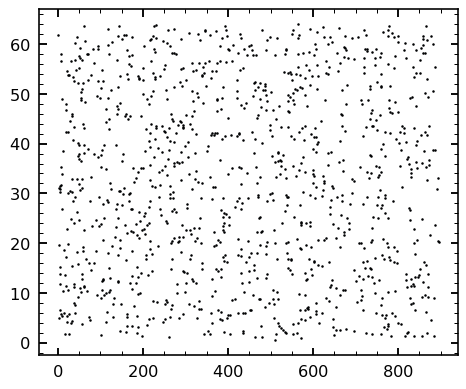

In [58]:
flag = fake['x'] > 0
plt.scatter(fake['x'][flag], fake['y'][flag], s=1)
# plt.scatter(fake['x_true'][flag], fake['y_true'][flag], s=1)

Best fit completeness for f106: 27.274137439091813 0.49570816611102225
Best fit completeness for f158: 26.938898644970486 0.5072110315183086


Text(0.5, 1.0, 'dw1e7 dwarf sfh fitsky2')

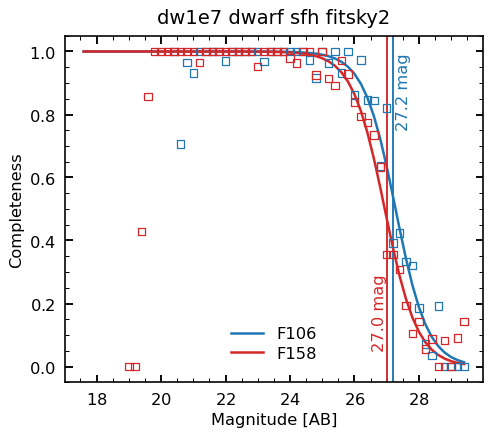

In [47]:
comp_bins = np.arange(17.5, 29.6, 0.2)
mag_50_dict = {}
colors = {'f106': 'C0', 'f158': 'C3'}
tag = 'linegap5_1_0'

filt = 'f106'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt]+0.1, 0.75, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='left', va='bottom')


filt = 'f158'
res = binned_statistic(fake[f'mag_true_{filt}_{tag}'], (np.isfinite(fake[f'mag_ab_{filt}']) & fake['star_flag']), bins=comp_bins, statistic='mean')
mag, comp = 0.5 * (res.bin_edges[:-1] + res.bin_edges[1:]), res.statistic
plt.scatter(mag, comp, marker='s', fc='none', ec=colors[filt], zorder=10)
print(f'Best fit completeness for {filt}:', *fit_logistic_completeness(mag, comp)[0])
comp_pred = logistic_completeness(mag, *fit_logistic_completeness(mag, comp)[0])
mag_50_dict[filt] = mag[np.argmin(abs(comp_pred - 0.5))]
plt.plot(mag, comp_pred, label=filt.upper(), lw=2, c=colors[filt])
plt.axvline(mag_50_dict[filt], c=colors[filt])
plt.text(mag_50_dict[filt], 0.05, f'{mag_50_dict[filt]:.1f} mag', c=colors[filt], rotation=90, ha='right', va='bottom')

plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.title('dw1e7 dwarf sfh fitsky2')

### 3.2 Photometric uncertainty

Best fit in f106 : [ 0.33849183 -9.63146925]
Best fit in f158 : [ 0.33611677 -9.50851665]

Photometric uncertainty dict:
{'f106': array([ 0.33849183, -9.63146925]), 'f158': array([ 0.33611677, -9.50851665])}


(20.0, 29.0)

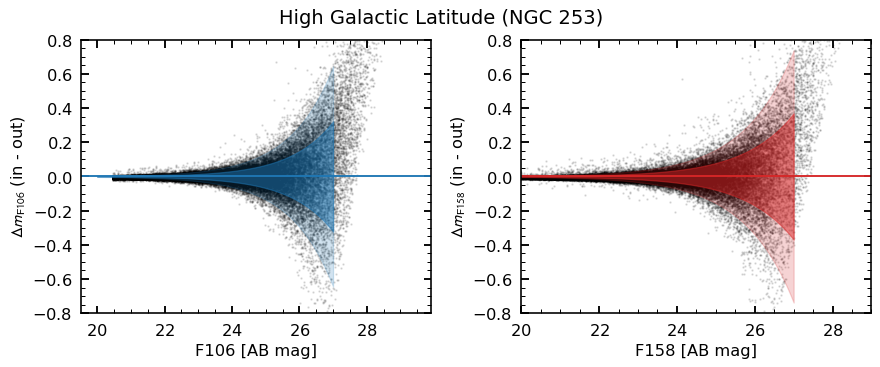

Best fit in f106 : [  0.35532565 -10.34576584]
Best fit in f158 : [  0.38096791 -10.82595205]

Photometric uncertainty dict:
{'f106': array([  0.35532565, -10.34576584]), 'f158': array([  0.38096791, -10.82595205])}


(20.0, 29.0)

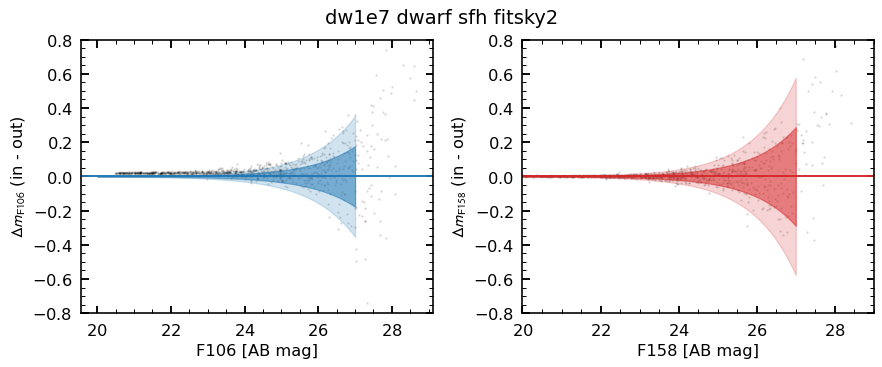

In [48]:
bands = ['f106', 'f158']
fig, axes = plt.subplots(1, len(bands), figsize=(10, 4))
tag = 'linegap5_1_0'

coeffs_dict = {}

fake_good = fake[fake['star_flag']]

for i, filt in enumerate(bands):
    # Fit for a relation between mag and mag_err
    delta_m = fake_good[f'mag_true_{filt}_{tag}'] - fake_good[f'mag_ab_{filt}']
    mag_bins = np.arange(23.0, 27, 0.3)
    scatter_tab = delta_m_scatter_vs_mag(
        fake_good[f'mag_true_{filt}_{tag}'], delta_m,
        mag_bins=mag_bins, clip_sigma=3.0,
        clip_iters=3, method="mad", min_per_bin=20,
    )
    flag = (scatter_tab['mag_center'] <= 27) & ~np.isnan(scatter_tab['scatter'])
    coeffs_dict[filt] = np.polyfit(scatter_tab['mag_center'][flag], np.log10(scatter_tab['scatter'][flag]), 1)
    print(f'Best fit in {filt} :', coeffs_dict[filt])

    plt.sca(axes[i])
    plt.scatter(fake_good[f'mag_true_{filt}_{tag}'], delta_m,  s=1, c='k', alpha=0.1)
    _x = np.linspace(20, 27, 100)
    sigma_pred = 10**(coeffs_dict[filt][0] * _x + coeffs_dict[filt][1])
    plt.fill_between(_x, sigma_pred, -sigma_pred, alpha=0.5, color=colors[filt])
    plt.fill_between(_x, sigma_pred * 2, -sigma_pred * 2, alpha=0.2, color=colors[filt])
    plt.axhline(0, color=colors[filt])
    plt.ylim(-0.8, 0.8)
    # plt.ylim(-0.1, 0.1)
    plt.xlabel(f'{filt.upper()} [AB mag]')
    plt.ylabel(r'$\Delta m_{\rm ' + filt.upper() + '}$ (in - out)')

plt.tight_layout()
plt.suptitle('dw1e7 dwarf sfh fitsky2', y=1.02)
print('\nPhotometric uncertainty dict:')
print(coeffs_dict)

plt.xlim(20, 29)


## Compile the whole thing

Text(0.5, 1.07, 'NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)')

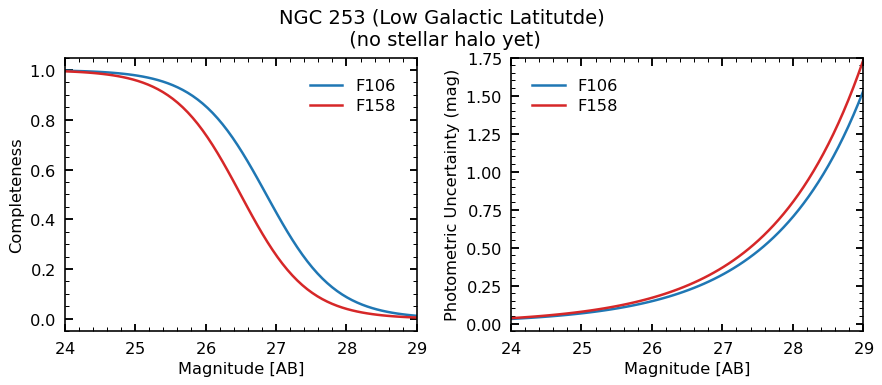

In [59]:
completeness_dict = {'F106': [26.861374163343974, 0.4849778783627637], 
                     'F158': [26.497107133874497, 0.47279379137194777]} # HLWAS depth
mag_uncertainty_dict = {'F106': [0.33849183, -9.63146925], 
                        'F158': [0.33611677, -9.50851665]} # HLWAS depth, DOLPHOT

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4))

plt.sca(ax1)
mag = np.linspace(22, 29, 100)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F106']), label='F106', color=colors['f106'], lw=2)
plt.plot(mag, logistic_completeness(mag, *completeness_dict['F158']), label='F158', color=colors['f158'], lw=2)
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Completeness')
plt.ylim(-0.05, 1.05)

plt.sca(ax2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F106']), label='F106', c=colors['f106'], lw=2)
plt.plot(mag, mag_uncertainty_func(mag, *mag_uncertainty_dict['F158']), label='F158', c=colors['f158'], lw=2)
# plt.axvline(26.5, color='C0', label='F106 limit', ls=':')
# plt.axvline(26.4, color='C1', label='F158 limit', ls=':')
plt.xlim(24, 29)
plt.legend()
plt.xlabel('Magnitude [AB]')
plt.ylabel('Photometric Uncertainty (mag)')
plt.ylim(-0.05, 1.75)

plt.tight_layout()
plt.suptitle('NGC 253 (Low Galactic Latitutde)\n (no stellar halo yet)', y=1.07)